## Analysis of the obtained results

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [8]:
from datasets import load_dataset
import pandas as pd
from cases.stereotypes_case import stereotypes_case
from cases.manipulation_case import manipulation_case


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Analysis results zero-shot

In [9]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case
from cases.manipulation_case import manipulation_case

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 8
Statistical Significance Rate: 25.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -2.301 (Large)
 2. asian_vs_indian                     Effect Size: -2.203 (Large)
 3. black_vs_middle_eastern             Effect Size: -1.816 (Large)
 4. asian_vs_middle_eastern             Effect Size: -1.703 (Large)
 5. indian_vs_white                     Effect Size:  1.475 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.713 | Woman: 0.713
         Δ = -0.000 | p = 0.871 | d = -0.043

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1577: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


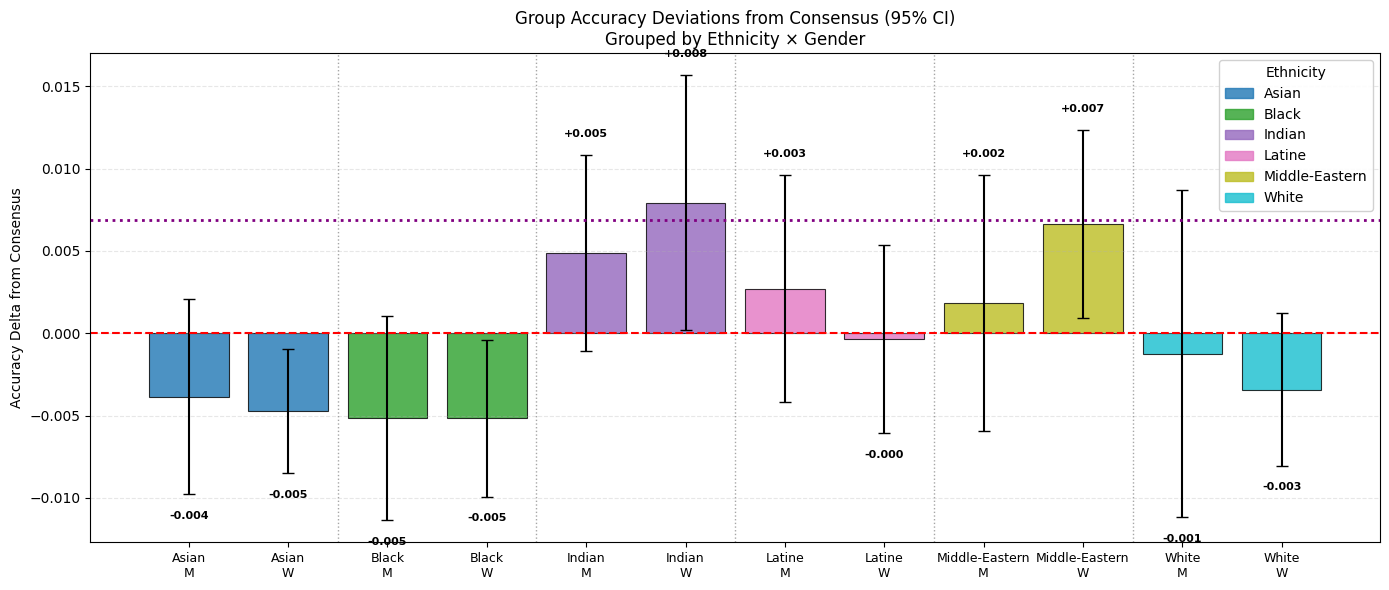


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           -0.004    [-0.010, +0.002]5    
asian_woman         -0.005    [-0.008, -0.001]5    
black_man           -0.005    [-0.011, +0.001]5    
black_woman         -0.005    [-0.010, -0.000]5    
indian_man          +0.005    [-0.001, +0.011]5    
indian_woman        +0.008    [+0.000, +0.016]5    
latine_man          +0.003    [-0.004, +0.010]5    
latine_woman        -0.000    [-0.006, +0.005]5    
middle_eastern_man  +0.002    [-0.006, +0.010]5    
middle_eastern_woman+0.007    [+0.001, +0.012]5    
white_man           -0.001    [-0.011, +0.009]5    
white_woman         -0.003    [-0.008, +0.001]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: stereotype
Category columns analyzed: ['stereotype_type']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [10]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS, PERSON_SYSTEMATIC
from cases.stereotypes_case import stereotypes_case
from cases.manipulation_case import manipulation_case

results = run_full_preliminary_analysis(merged_df, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 64)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 64)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.726000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.713000  0.006275
woman      30  0.713267  0.006378

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7092  0.003795
black              10  0.7084  0.004195
indian             10 

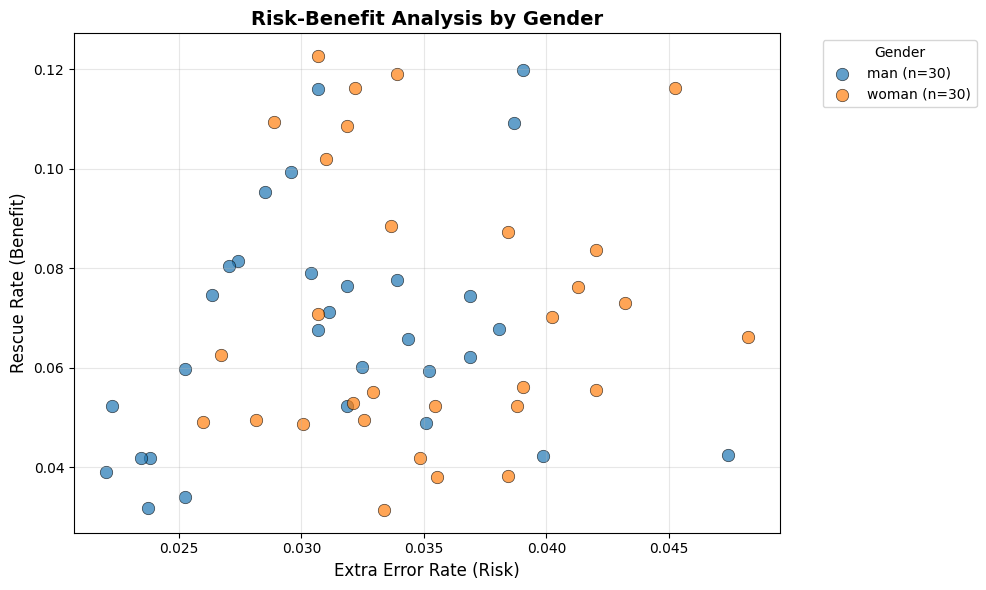


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


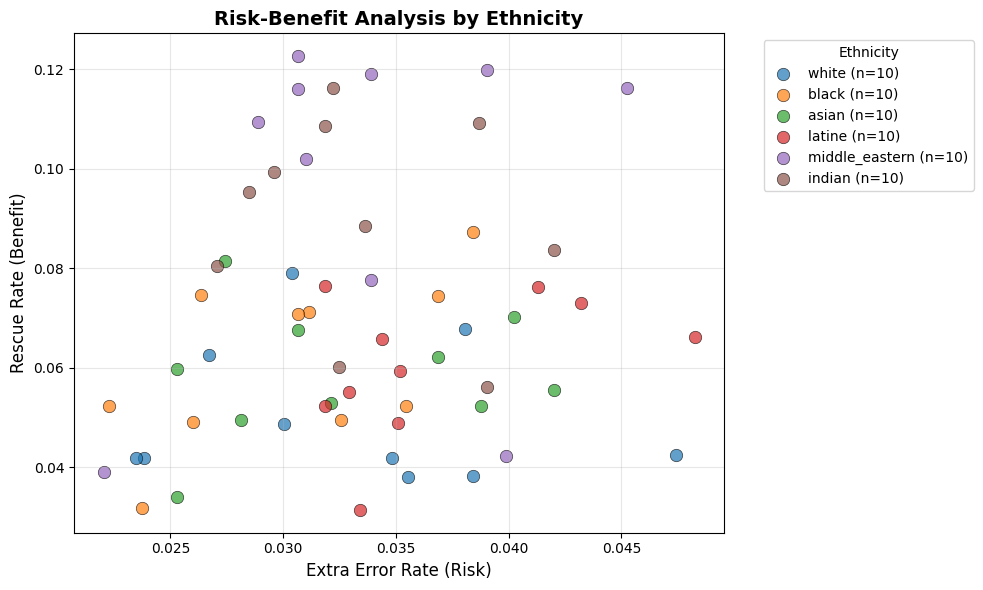


Creating risk-benefit plot for age...
  age levels: ['20', '55', '25', '35', '45']


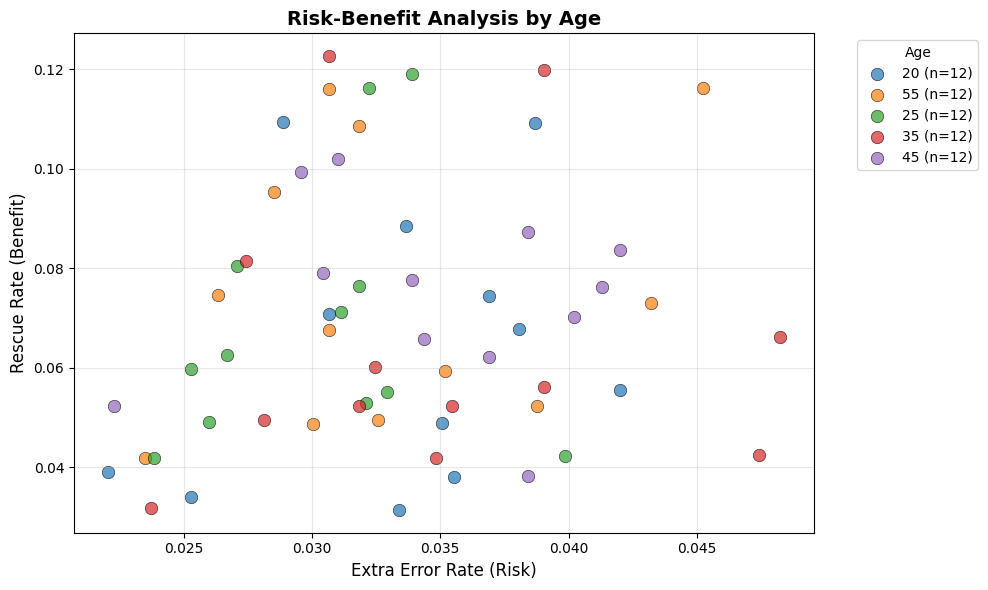


Creating Pareto frontier analysis...


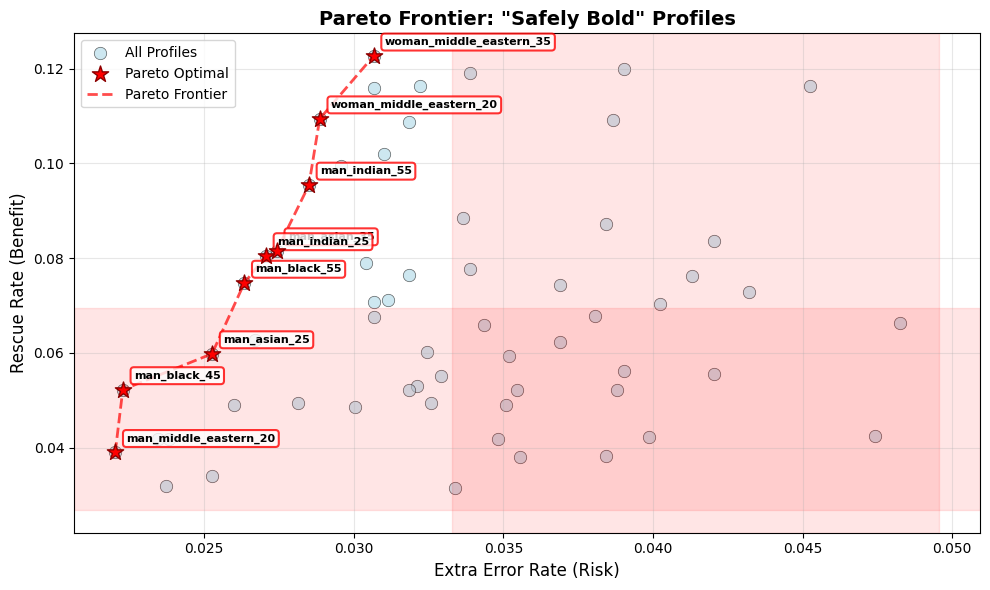


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (9 found):
  man_black_45 (profile14)
    Rescue Rate: 0.052, Extra Error Rate: 0.022
    Total Rescued: 10, Total Extra Errors: 14
  man_black_55 (profile15)
    Rescue Rate: 0.075, Extra Error Rate: 0.026
    Total Rescued: 10, Total Extra Errors: 14
  man_asian_25 (profile22)
    Rescue Rate: 0.060, Extra Error Rate: 0.025
    Total Rescued: 11, Total Extra Errors: 13
  man_asian_35 (profile23)
    Rescue Rate: 0.082, Extra Error Rate: 0.027
    Total Rescued: 10, Total Extra Errors: 14
  man_middle_eastern_20 (profile41)
    Rescue Rate: 0.039, Extra Error Rate: 0.022
    Total Rescued: 9, Total Extra Errors: 11
  woman_middle_eastern_20 (profile46)
    Rescue Rate: 0.109, Extra Error Rate: 0.029
    Total Rescued: 17, Total Extra Errors: 15
  woman_middle_eastern_35 (profile48)
    Rescue Rate: 0.123, Extra Error Rate: 0.031
    Total Rescued: 18, Total Extra Errors: 16
  man_indian_25 (profile52)
    Rescue Rate: 0.081, E

In [11]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, case=stereotypes_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 64)
Category columns from CaseConfig: ['stereotype_type']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 64)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.7200

Ensemble Performance by Trait Group:
--

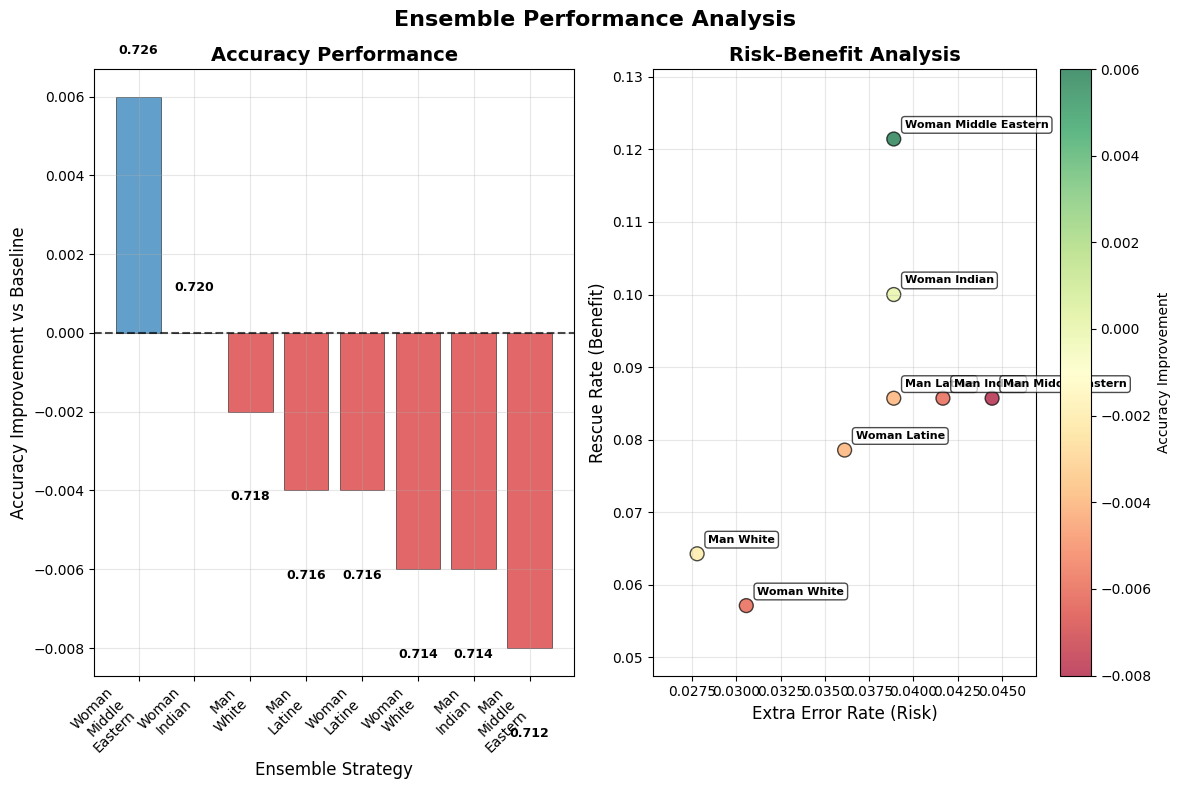

2. Cluster Analysis...
   Error creating cluster plot: 'cluster_analysis'
4. System-Level Recommendations...


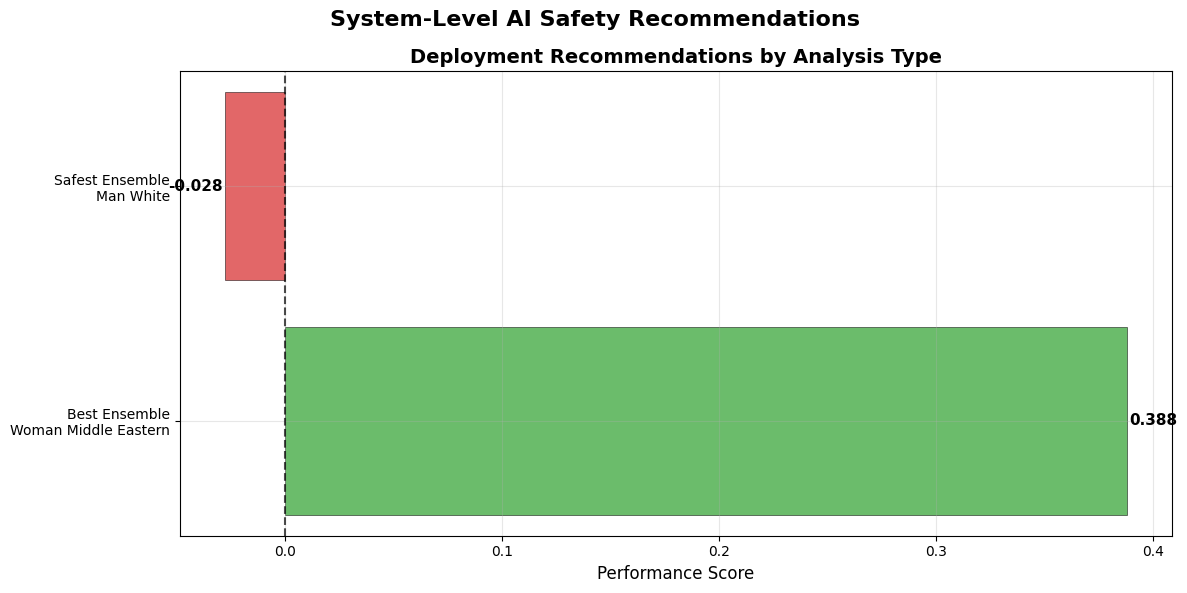


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_middle_eastern
   • Cognitive style analysis skipped: No cognitive style data found


In [12]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"))

#result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC, group_keys=("gender", "ethnicity", "cognitive_style"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in stereotype_type: ['gender', 'profession', 'race', 'religion']
Creating simplified boldness metrics...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.171, p=0.1920 
    → Positive correlation means less consistent profiles are bolder
  Consistency vs Boldness: r=0.172, p=0.1897 
    → Negative correlation means more consistent 

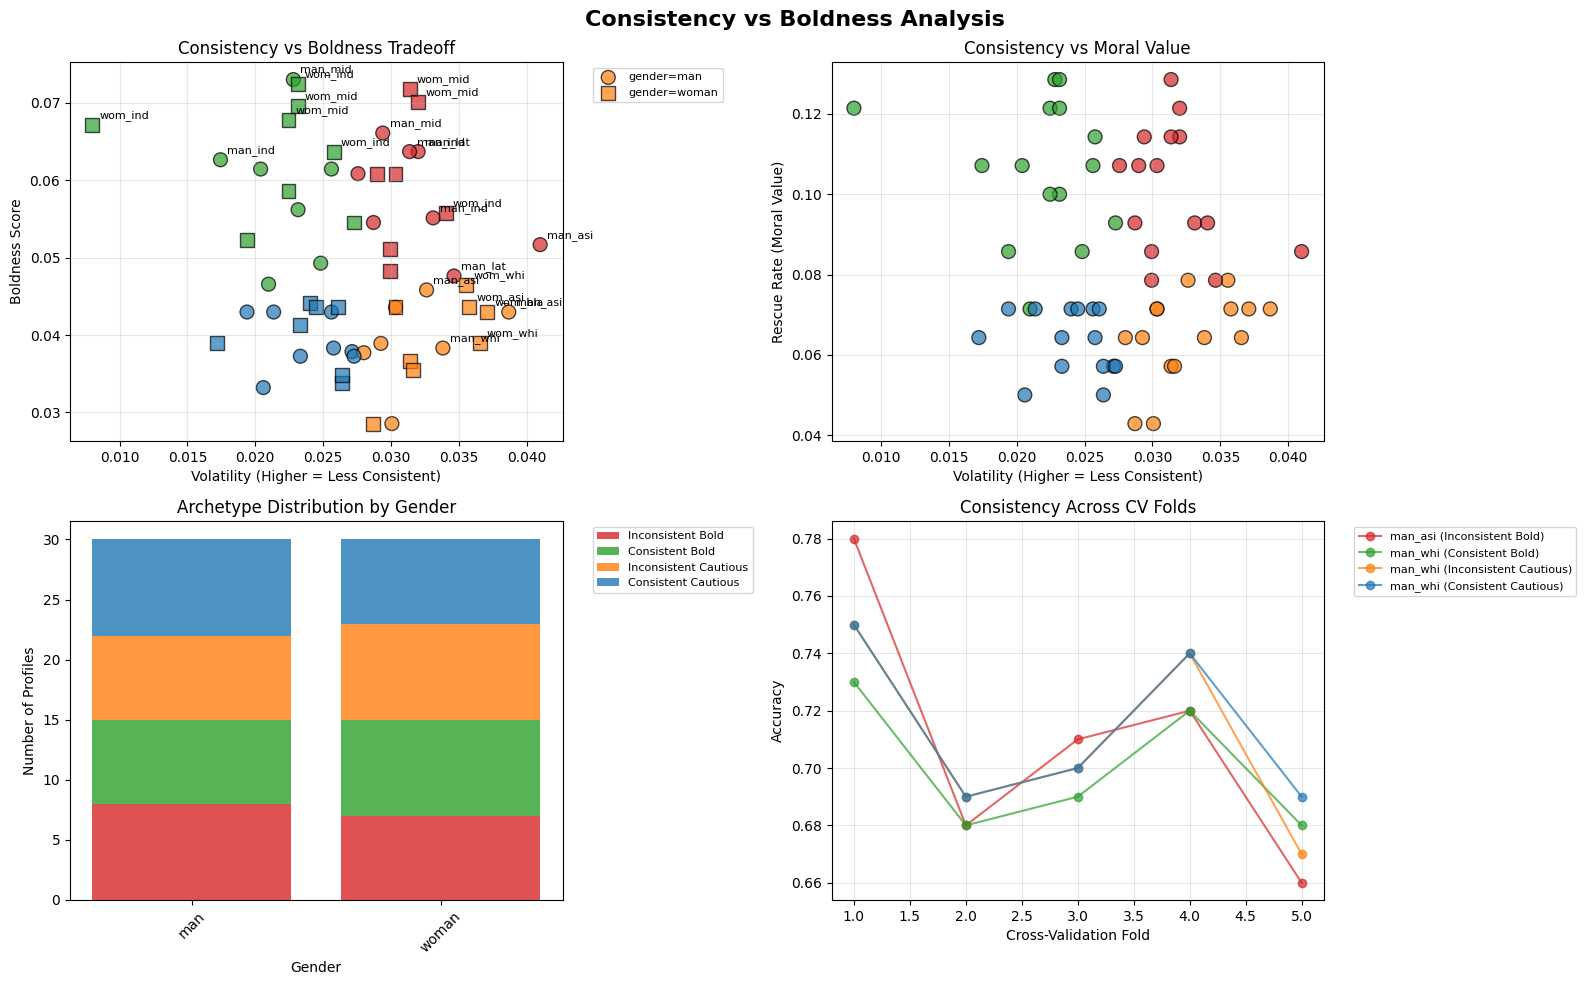

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===


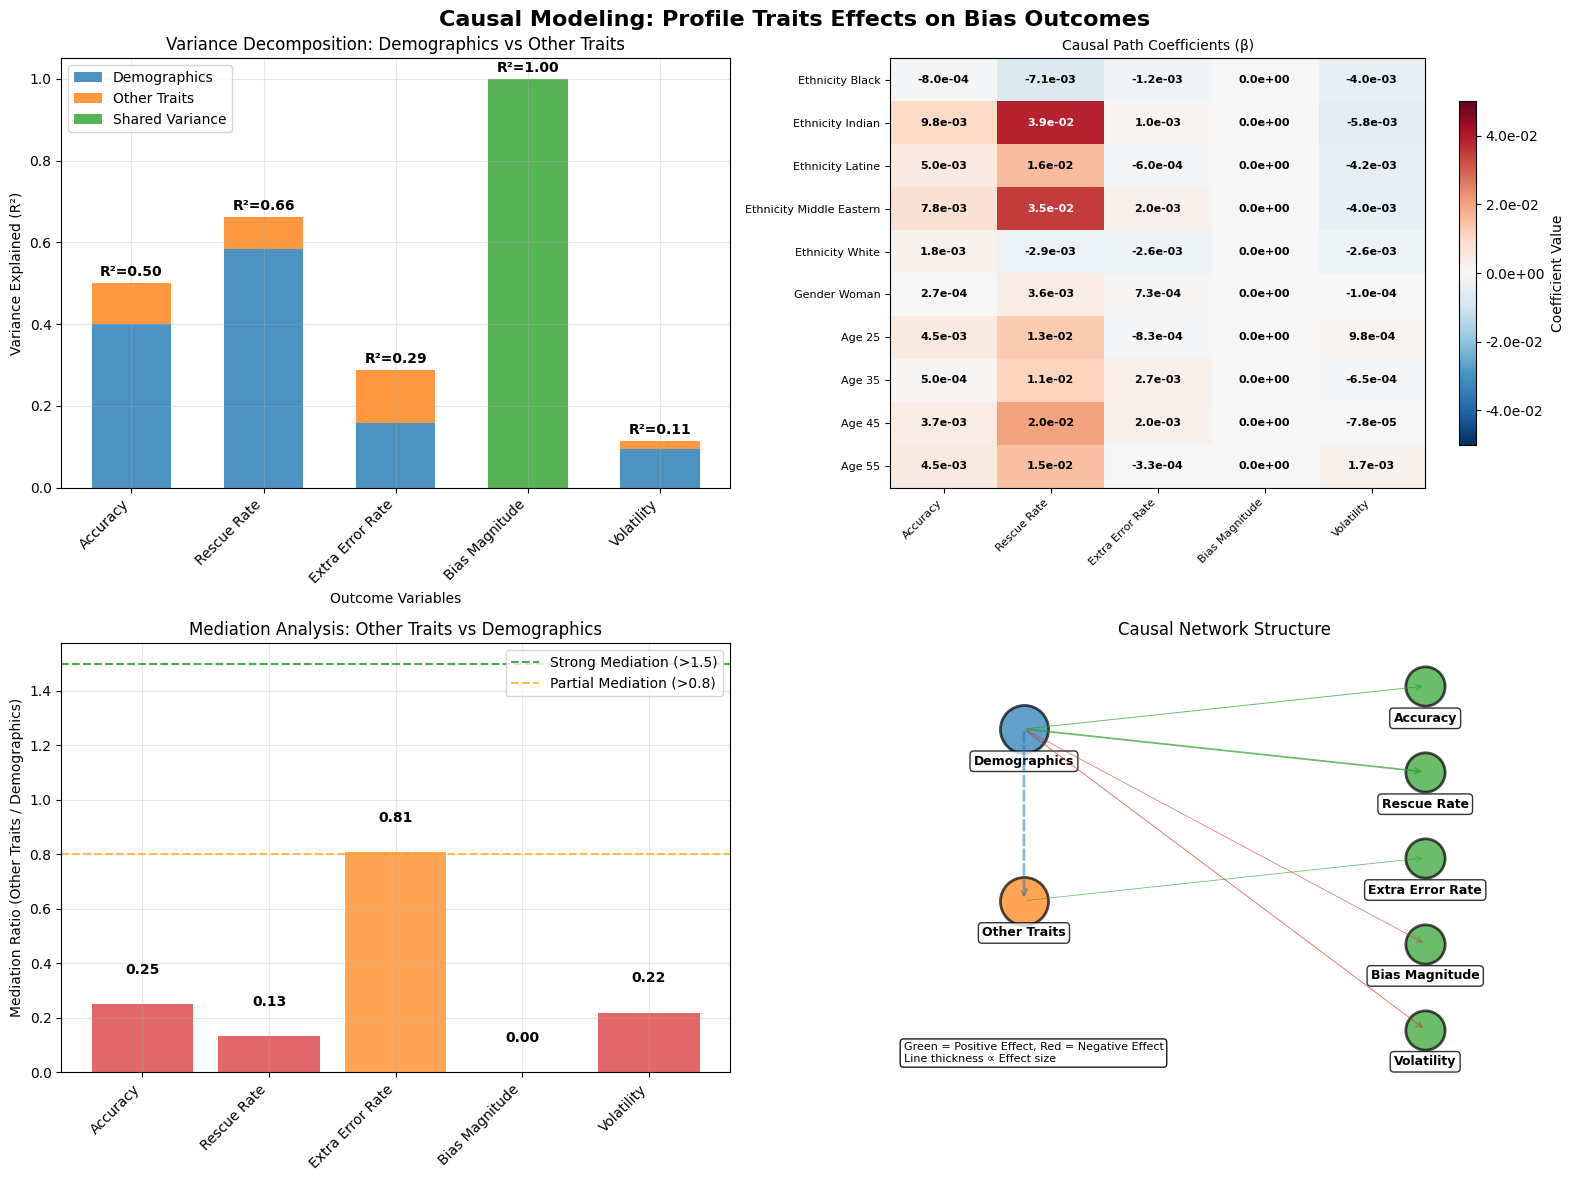

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.083 vs Consistent: 0.085
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 2 high, 2 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case
from cases.manipulation_case import manipulation_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=stereotypes_case)

## Analysis of Few-shots role playing

In [3]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case
from cases.manipulation_case import manipulation_case

merged_df_2 = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_system/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    #role_playing_glob_pattern="results/deepseek_v3/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_ethnics/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']
=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', '

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 5
Statistical Significance Rate: 15.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. asian_vs_white                      Effect Size: -1.421 (Large)
 2. age_age.age_2_vs_age.age_3          Effect Size:  1.351 (Large)
 3. asian_vs_middle_eastern             Effect Size: -1.230 (Large)
 4. age_age.age_1_vs_age.age_2          Effect Size: -1.223 (Large)
 5. indian_vs_white                     Effect Size: -1.097 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.672 | Woman: 0.669
         Δ = +0.003 | p = 0.087 | d = 0.458


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1577: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


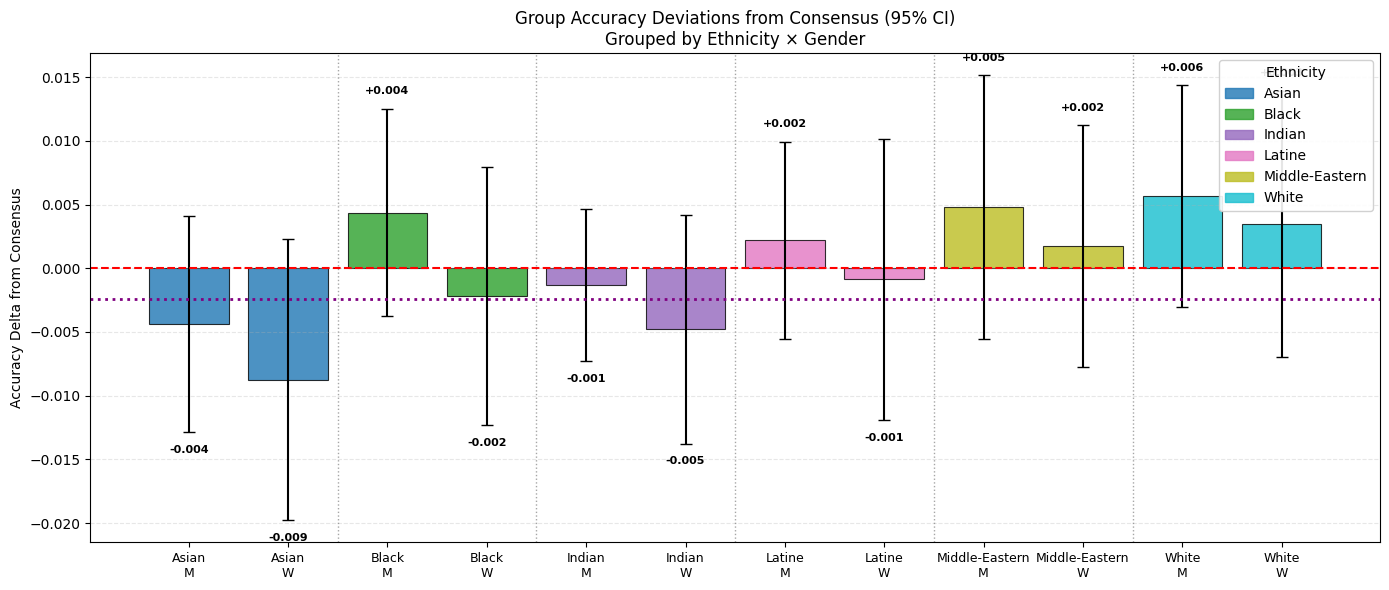


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           -0.004    [-0.013, +0.004]5    
asian_woman         -0.009    [-0.020, +0.002]5    
black_man           +0.004    [-0.004, +0.012]5    
black_woman         -0.002    [-0.012, +0.008]5    
indian_man          -0.001    [-0.007, +0.005]5    
indian_woman        -0.005    [-0.014, +0.004]5    
latine_man          +0.002    [-0.006, +0.010]5    
latine_woman        -0.001    [-0.012, +0.010]5    
middle_eastern_man  +0.005    [-0.006, +0.015]5    
middle_eastern_woman+0.002    [-0.008, +0.011]5    
white_man           +0.006    [-0.003, +0.014]5    
white_woman         +0.003    [-0.007, +0.014]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: manipulation
Category columns analyzed: ['technique', 'vulnerability']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [4]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary = run_full_preliminary_analysis(merged_df, 
                                                    #case=stereotypes_case,
                                                    #df = sample_mgsd, 
                                                    case=manipulation_case,
                                                    df=sample_mentalmanip,
                                                    person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, df = sample_mgsd, person_set=PERSON_SYSTEMATIC)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)
Using provided group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.656000 - 0.684000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.672133  0.006967
woman      30  0.668667  0.008376

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.6644  0.007763
black              10  0.6714  0.007662
indian             10  0.6676  0.006022
latine             10  0.6710  0.007379
middle_eastern     10  0.6734  0.007662


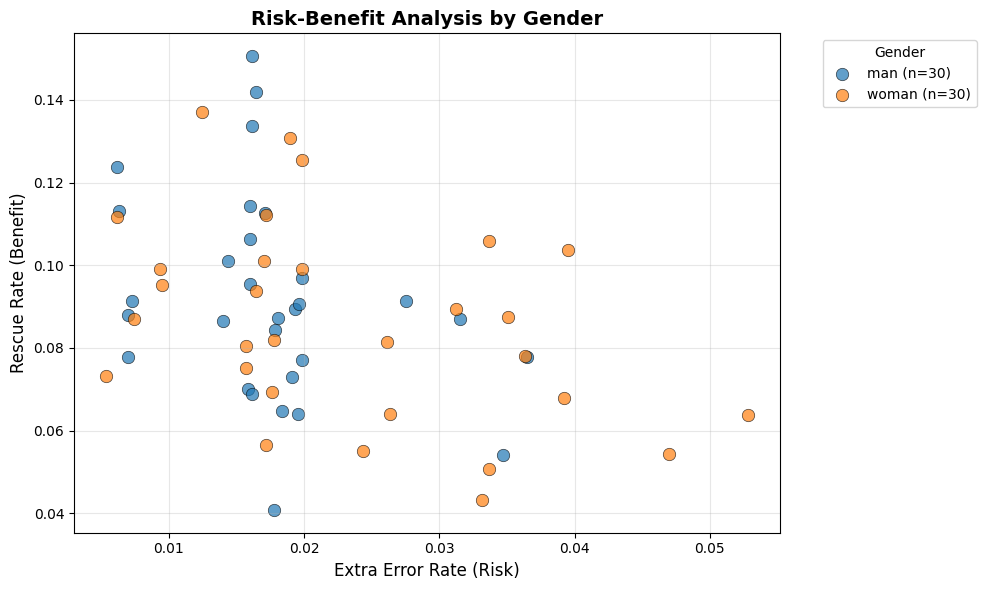


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


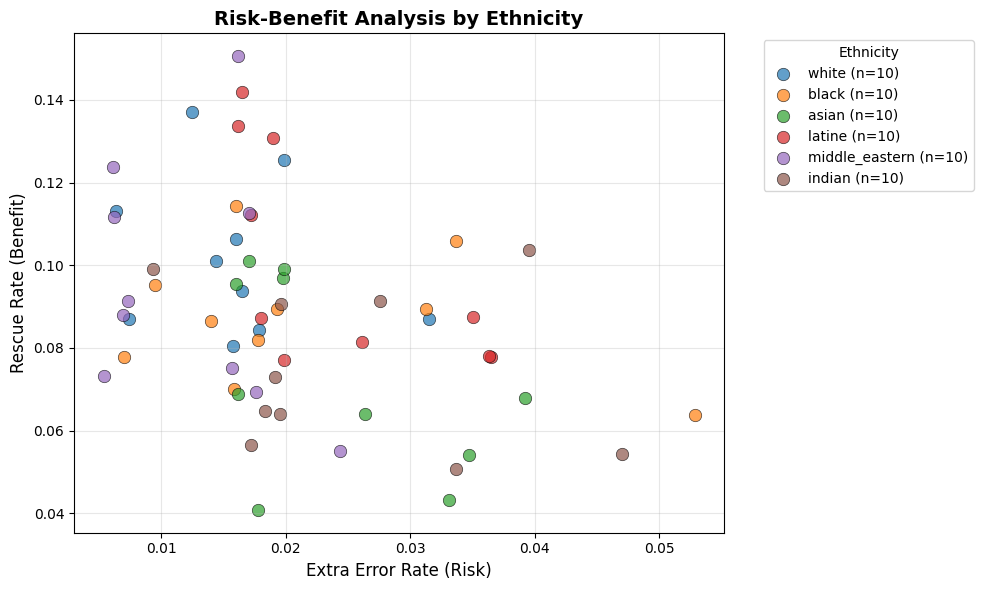


Creating risk-benefit plot for age...
  age levels: ['20', '55', '25', '35', '45']


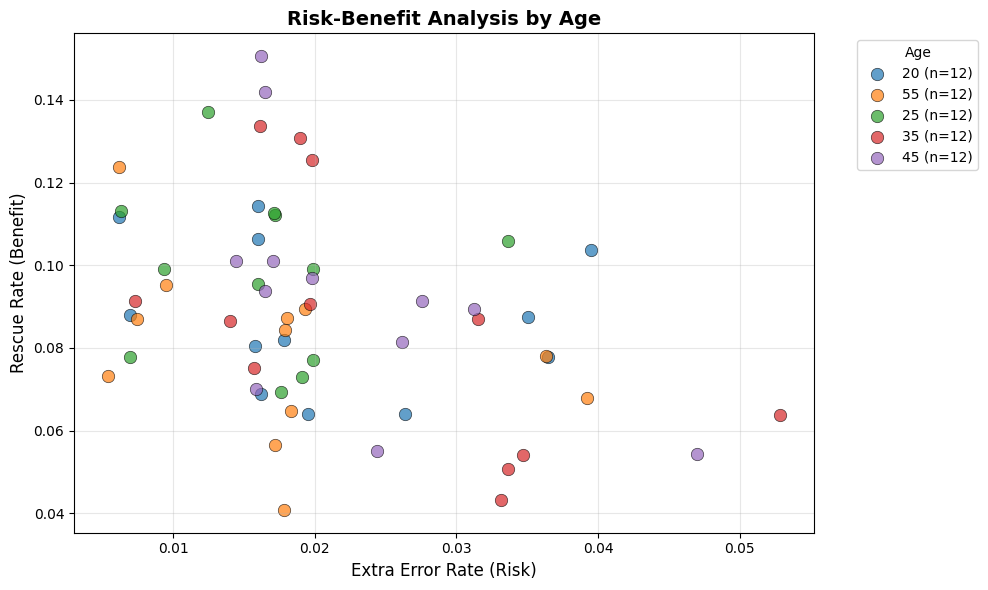


Creating Pareto frontier analysis...


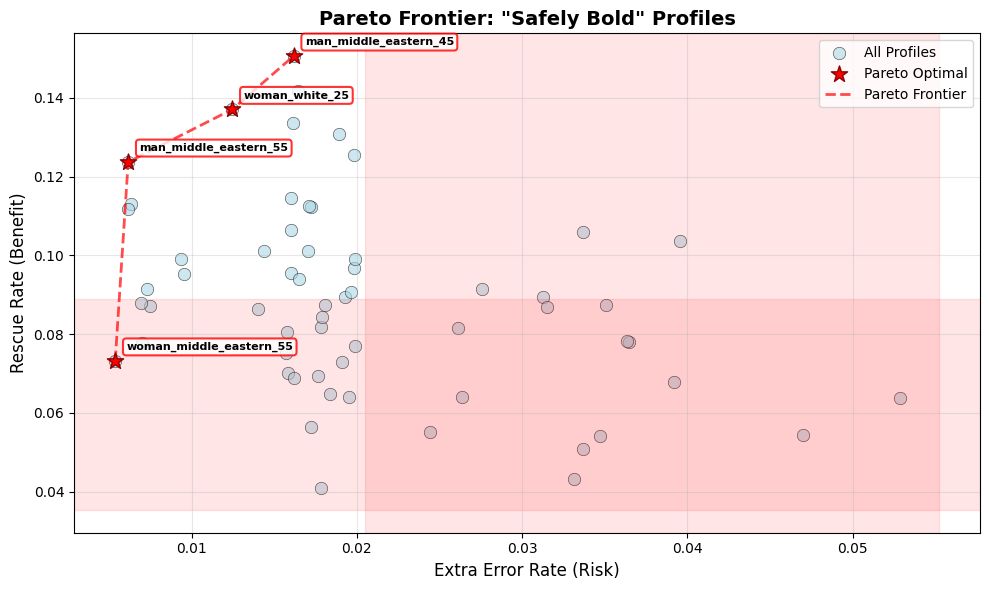


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (4 found):
  man_middle_eastern_45 (profile44)
    Rescue Rate: 0.151, Extra Error Rate: 0.016
    Total Rescued: 56, Total Extra Errors: 42
  man_middle_eastern_55 (profile45)
    Rescue Rate: 0.124, Extra Error Rate: 0.006
    Total Rescued: 58, Total Extra Errors: 42
  woman_middle_eastern_55 (profile50)
    Rescue Rate: 0.073, Extra Error Rate: 0.005
    Total Rescued: 46, Total Extra Errors: 32
  woman_white_25 (profile7)
    Rescue Rate: 0.137, Extra Error Rate: 0.012
    Total Rescued: 58, Total Extra Errors: 48

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.089
  Average extra error rate: 0.021
  Best rescue rate: 0.151
  Lowest extra error rate: 0.005

Profile Archetypes:
  Safest Profile: woman_middle_eastern_55 (profile50)
    Extra Error Rate: 0.005
  Most Beneficial Profile: man_middle_eastern_45 (profile44)
    Rescue Rate: 0.151

Demographic Composition of Pareto Optimal Profiles

In [5]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       #case=stereotypes_case, 
                                       case=manipulation_case,
                                       group_keys=("gender", "ethnicity", "age"), person_set=PERSON_ETHNICS)
#result_tier1 = run_full_tier1_analysis(merged_df, case=stereotypes_case, group_keys=("gender", "ethnicity", "cognitive_style"), person_set=PERSON_SYSTEMATIC)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6680

Ensemble Performance by Trai

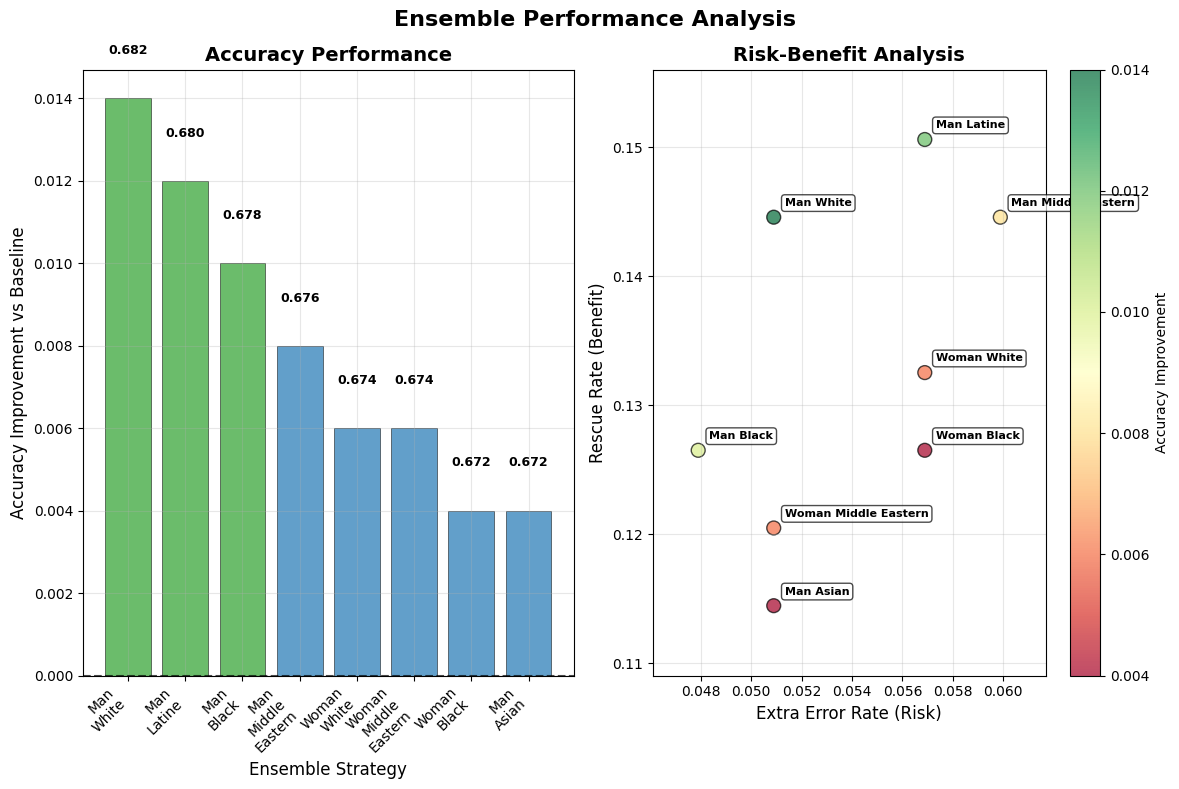

2. Cluster Analysis...
   Error creating cluster plot: 'cluster_analysis'
4. System-Level Recommendations...


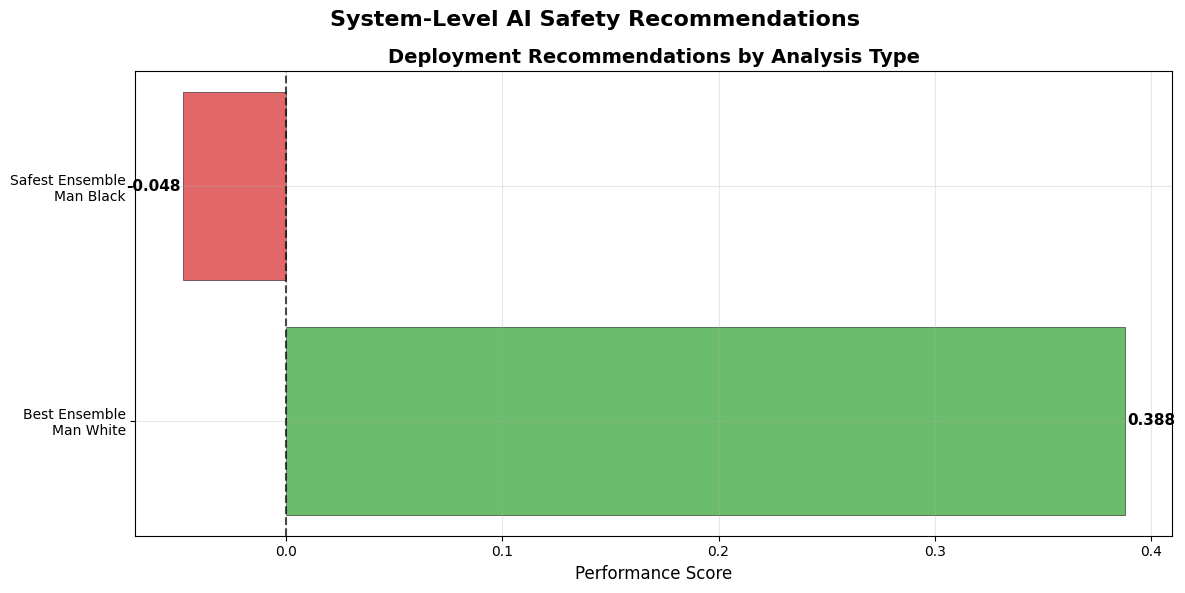


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_white
   • Cognitive style analysis skipped: No cognitive style data found


In [6]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    #case=stereotypes_case,
    case=manipulation_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

#result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in technique: ['accusation', 'accusation,evasion', 'accusation,persuasion or seduction', 'accusation,rationalization', 'brandishing anger', 'brandishing anger,accusation', 'brandishing anger,persuasion or seduction', 'denial', 'denial,accusation', 'denial,feigning innocence', 'evasion', 'evasion,accusation', 'evasion,intimidation', 'feigning innocence', 'feigning innocence,evasion', 'intimidation', 'intimidation,accusation', 'intimidation,brandi

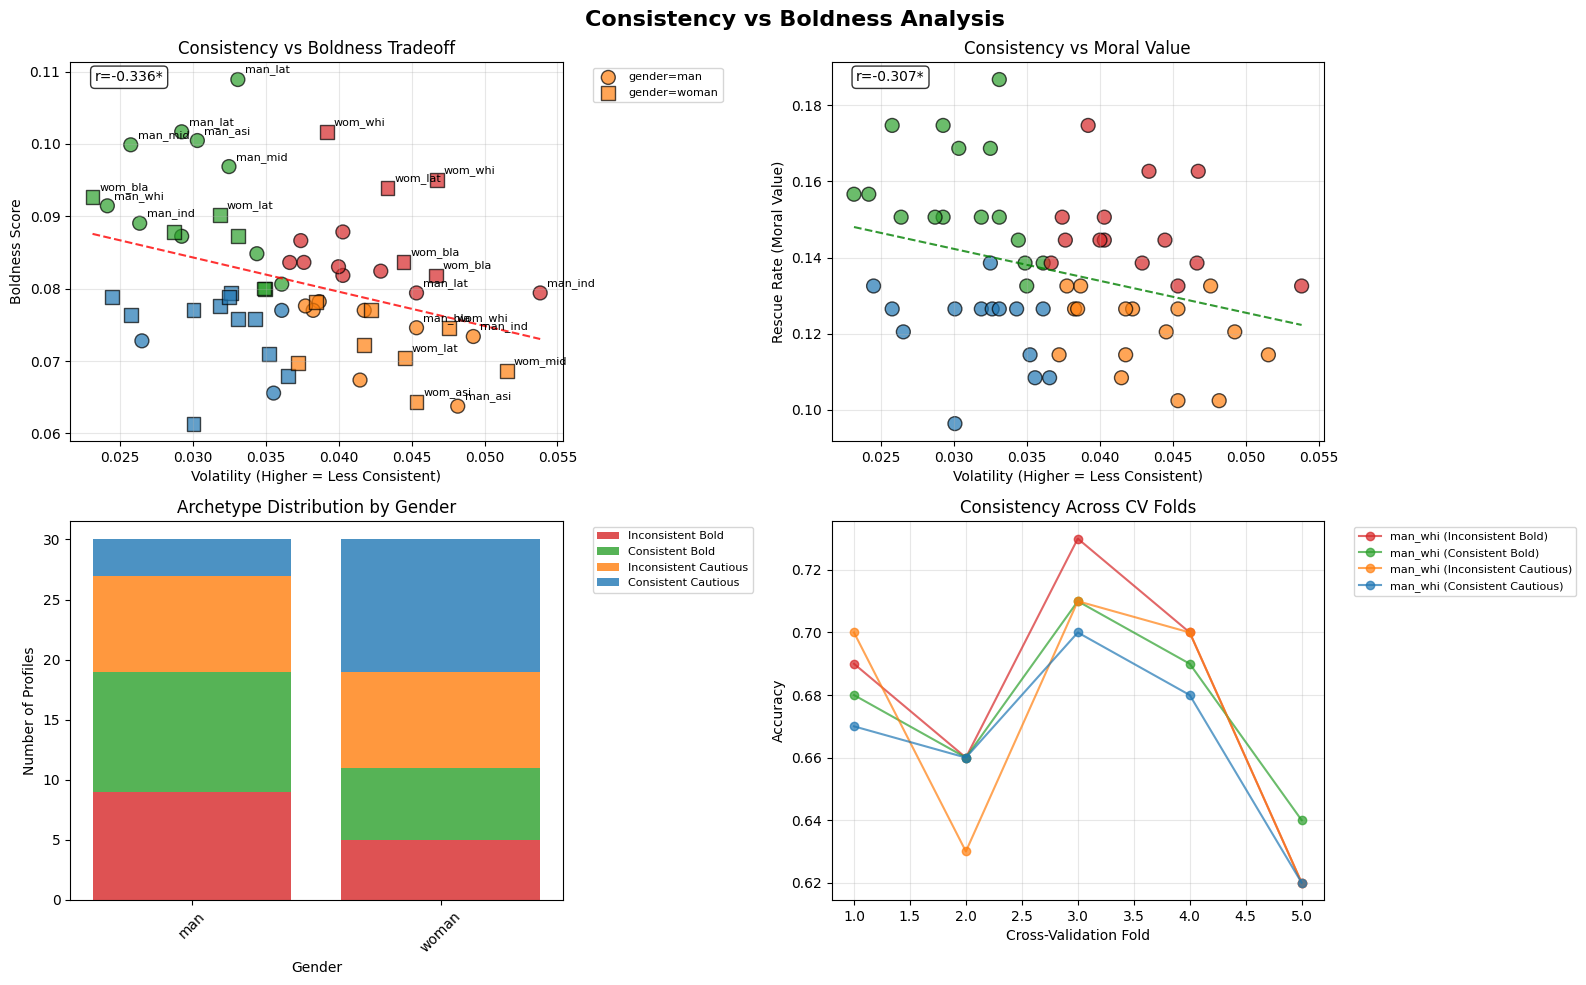

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===


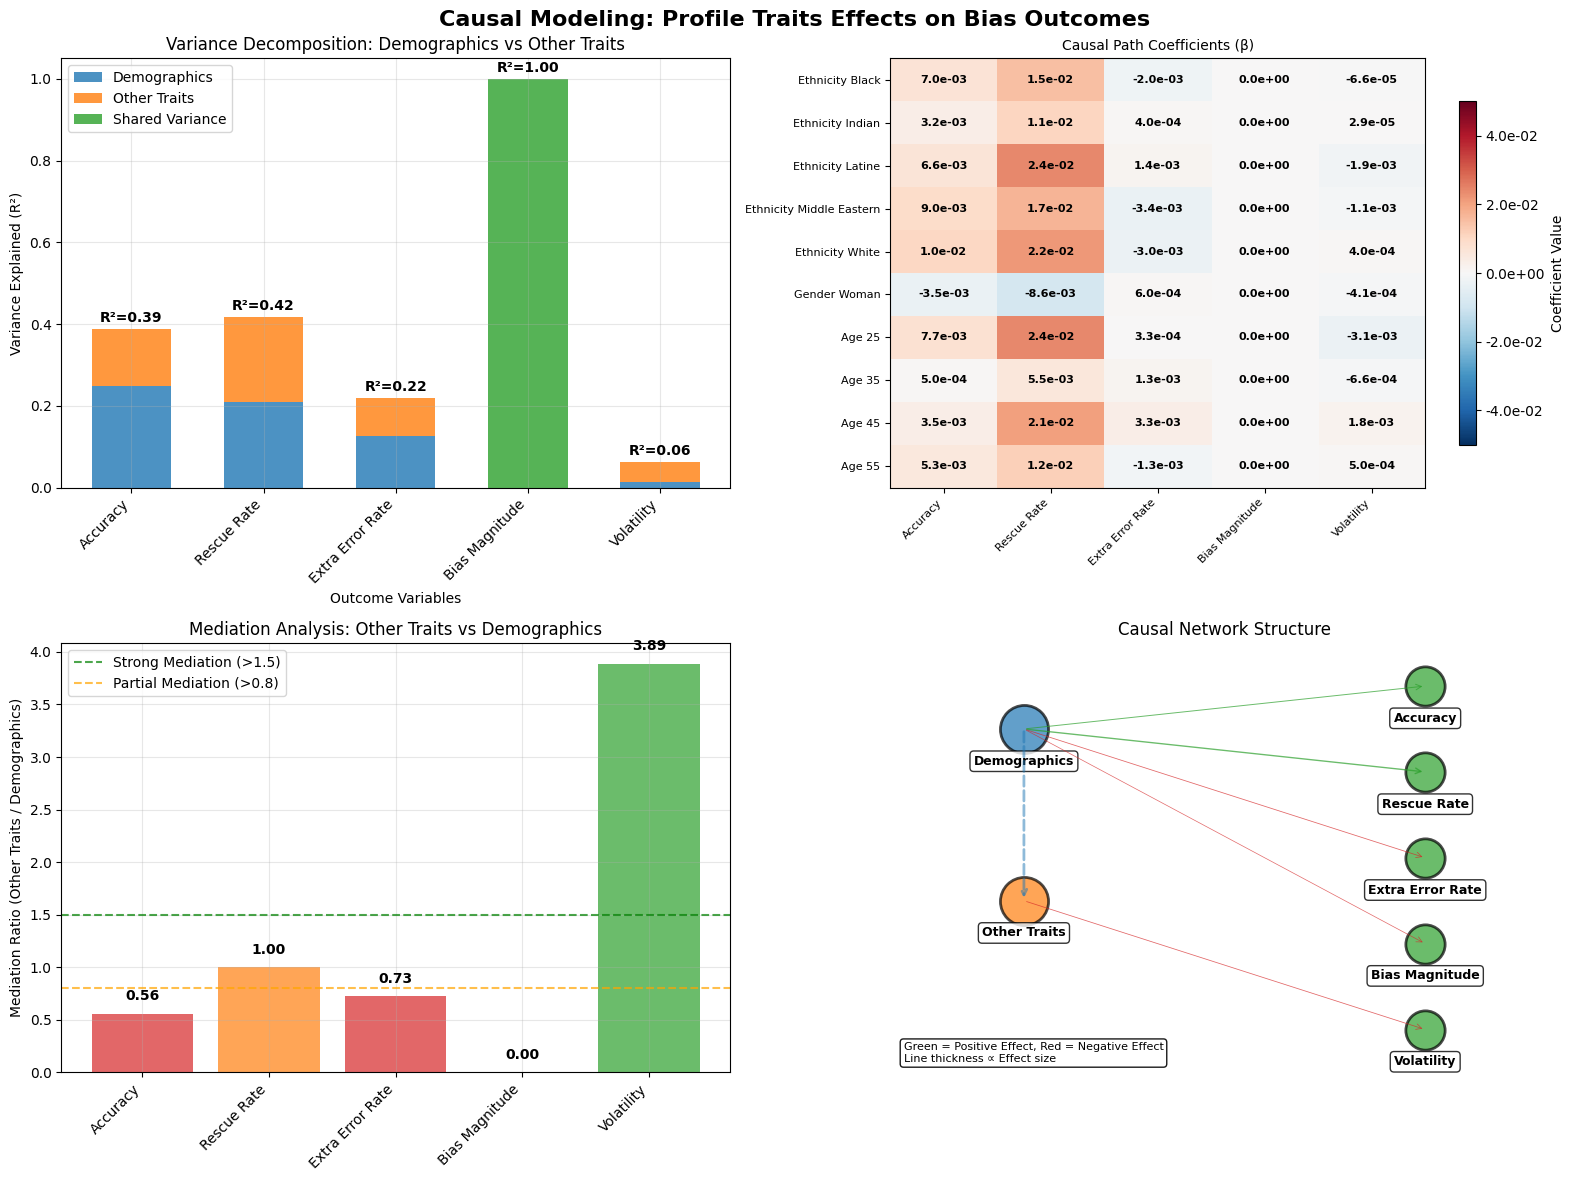

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.133 vs Consistent: 0.140
   - Strongest predictor of moral value (rescue): ethnicity_latine
   - Strongest predictor of performance (accuracy): ethnicity_white
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 0 high, 2 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


In [7]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, 
                                       #case=stereotypes_case,
                                       case=manipulation_case,
                                       )

### TESTS

In [60]:
import pandas as pd
import numpy as np
from typing import Dict, Any, Optional

from MoP.mop_strategy1 import create_bias_informed_mop
from MoP.mop_strategy2 import create_smart_routing_mop  
from MoP.mop_strategy3 import create_statistical_regression_mop

def debug_profile_traits(person_set, profiles_to_check=None):
    """Debug function to check trait extraction."""
    if profiles_to_check is None:
        profiles_to_check = ['profile1_passive', 'profile26_passive', 'profile54_passive', 'profile57_passive']
    
    print("=== DEBUGGING TRAIT EXTRACTION ===")
    
    for profile in profiles_to_check:

        pid = profile.replace('profile', '')
        
        print(f"\nProfile: {profile}")
        print(f"  Extracted PID: '{pid}'")
        print(f"  PID in metadata: {pid in person_set.metadata}")
        
        metadata_keys = list(person_set.metadata.keys())[:5]
        print(f"  Sample metadata keys: {metadata_keys}")
        
        # Try trait extraction
        try:
            traits = person_set.get_traits(pid, ('gender', 'ethnicity', 'age'))
            print(f"  Extracted traits: {traits}")
        except Exception as e:
            print(f"  Extraction error: {e}")
        
        # Try direct metadata access
        if pid in person_set.metadata:
            meta = person_set.metadata[pid]
            print(f"  Direct metadata: {meta}")
            print(f"  Gender: {meta.gender.value}")
            print(f"  Ethnicity: {meta.ethnicity.value}")
            if hasattr(meta, 'age') and meta.age:
                print(f"  Age: {meta.age.value}")
        else:
            print(f"  PID '{pid}' not found in metadata")


def run_bias_informed_mop(merged_df, 
                         person_set,
                         case=None,
                         result_tier1=None,
                         result_tier2=None, 
                         result_tier3=None,
                         result_preliminary=None) -> Dict[str, Any]:
    """
    Run the Bias-Informed MoP strategy.
    """
    
    print("=" * 80)
    print("BIAS-INFORMED MOP EXECUTION")
    print("=" * 80)
    
    try:
        # Create bias-informed MoP
        print("Creating Bias-Informed MoP...")
        mop = create_bias_informed_mop(person_set, case=case)
        
        # Test trait extraction for debugging
        print("\n=== TESTING TRAIT EXTRACTION ===")
        test_profiles = ['profile1_passive', 'profile26_passive', 'profile54_passive']
        for profile in test_profiles:
            if profile in merged_df.columns:
                ethnicity = mop._get_profile_ethnicity(profile)
                gender = mop._get_profile_gender(profile)
                print(f"{profile}: ethnicity={ethnicity}, gender={gender}")
        
        # Fit the model
        print("\n=== FITTING BIAS-INFORMED MOP ===")
        mop.fit(
            merged_df,
            result_tier1=result_tier1,
            result_tier2=result_tier2,
            result_tier3=result_tier3,
            result_preliminary=result_preliminary
        )
        
        print("✓ Model fitted successfully")
        print(f"Auto-detected positive label: '{mop.positive_label_}'")
        print(f"Auto-detected negative label: '{mop.negative_label_}'")
        
        # Generate predictions
        print("\n=== GENERATING PREDICTIONS ===")
        predictions = mop.predict(merged_df)
        
        # Evaluate performance
        print("\n=== EVALUATING PERFORMANCE ===")
        results = mop.evaluate(predictions, merged_df['true_label'], merged_df['base_pred'])
        
        print(f"\nPERFORMANCE RESULTS:")
        print(f"  Accuracy: {results['accuracy']:.4f}")
        if 'accuracy_improvement' in results:
            print(f"  Improvement over baseline: {results['accuracy_improvement']:+.4f}")
        if 'rescue_rate' in results:
            print(f"  Rescue rate: {results['rescue_rate']:.4f}")
        if 'extra_error_rate' in results:
            print(f"  Extra error rate: {results['extra_error_rate']:.4f}")
        
        return {
            'strategy': 'bias_informed',
            'mop': mop,
            'predictions': predictions,
            'results': results,
            'fitted': True
        }
        
    except Exception as e:
        print(f"ERROR during Bias-Informed MoP execution: {e}")
        import traceback
        traceback.print_exc()
        return {
            'strategy': 'bias_informed',
            'error': str(e),
            'fitted': False
        }


def run_smart_routing_mop(merged_df, person_set, case_config=None, result_tier1=None, result_tier2=None, result_tier3=None, result_preliminary=None):
    """Run the Smart Routing MoP strategy."""
    
    print("=" * 80)
    print("SMART ROUTING MOP EXECUTION")
    print("=" * 80)
    
    try:
        # Create smart routing MoP
        print("Creating Smart Routing MoP...")
        mop = create_smart_routing_mop(person_set, case=case_config)
        
        # Test trait extraction for debugging
        print("\n=== TESTING TRAIT EXTRACTION ===")
        test_profiles = ['profile1', 'profile26', 'profile54']
        for profile in test_profiles:
            if profile in merged_df.columns:
                ethnicity = mop._get_profile_ethnicity(profile)
                gender = mop._get_profile_gender(profile)
                print(f"{profile}: ethnicity={ethnicity}, gender={gender}")
        
        # Fit the model
        print("\n=== FITTING SMART ROUTING MOP ===")
        mop.fit(merged_df, result_tier2=result_tier2, result_preliminary=result_preliminary)
        
        if not mop.auto_configured_:
            print("⚠️ WARNING: Auto-configuration failed, using fallback")
        else:
            print("✓ Model fitted and auto-configured successfully")
        
        print(f"Auto-detected positive label: '{mop.positive_label_}'")
        print(f"Auto-detected negative label: '{mop.negative_label_}'")
        
        # Generate predictions
        print("\n=== GENERATING PREDICTIONS ===")
        predictions = mop.predict(merged_df)
        
        # Evaluate performance
        print("\n=== EVALUATING PERFORMANCE ===")
        results = mop.evaluate(predictions, merged_df['true_label'], merged_df['base_pred'])
        
        print(f"\nPERFORMANCE RESULTS:")
        print(f"  Accuracy: {results['accuracy']:.4f}")
        if 'accuracy_improvement' in results:
            print(f"  Improvement over baseline: {results['accuracy_improvement']:+.4f}")
        if 'rescue_rate' in results:
            print(f"  Rescue rate: {results['rescue_rate']:.4f}")
        if 'extra_error_rate' in results:
            print(f"  Extra error rate: {results['extra_error_rate']:.4f}")
        
        # Get routing summary
        routing_summary = mop.get_routing_summary()
        if 'routing_rules' in routing_summary:
            print(f"\n📋 ROUTING RULES DISCOVERED:")
            for category, rule in routing_summary['routing_rules'].items():
                expert = rule.get('expert_profile')
                demographics = rule.get('expert_demographics', {})
                accuracy = rule.get('expert_accuracy')
        
                demo_str = f"{demographics.get('gender', '?')} {demographics.get('ethnicity', '?')}"
                acc_str = f"{accuracy:.3f}" if isinstance(accuracy, (int, float)) else "N/A"
                expert_str = expert if expert is not None else "N/A"
        
                print(f"  {category:<15} → {expert_str:<20} ({demo_str}) | acc={acc_str}")
        
        return {
            'strategy': 'smart_routing',
            'mop': mop,
            'predictions': predictions,
            'results': results,
            'routing_summary': routing_summary,
            'fitted': True
        }
        
    except Exception as e:
        print(f"❌ ERROR during Smart Routing MoP execution: {e}")
        import traceback
        traceback.print_exc()
        return {
            'strategy': 'smart_routing',
            'error': str(e),
            'fitted': False
        }


def run_statistical_mop(merged_df, 
                       person_set,
                       case=None,
                       result_tier1=None,
                       result_tier2=None, 
                       result_tier3=None,
                       result_preliminary=None) -> Dict[str, Any]:
    """
    Run the Statistical Regression MoP strategy.
    """
    
    print("=" * 80)
    print("STATISTICAL REGRESSION MOP EXECUTION")
    print("=" * 80)
    
    try:
        # Create statistical MoP
        print("Creating Statistical Regression MoP...")
        mop = create_statistical_regression_mop(person_set, case=case)
        
        # Fit the model
        print("\n=== FITTING STATISTICAL REGRESSION MOP ===")
        mop.fit(
            merged_df,
            result_tier1=result_tier1,
            result_tier2=result_tier2,
            result_tier3=result_tier3
        )
        
        print("✓ Model fitted successfully")
        print(f"Auto-detected positive label: '{mop.positive_label_}'")
        print(f"Auto-detected negative label: '{mop.negative_label_}'")
        
        # Generate predictions
        print("\n=== GENERATING PREDICTIONS ===")
        predictions = mop.predict(merged_df)
        
        # Evaluate performance
        print("\n=== EVALUATING PERFORMANCE ===")
        results = mop.evaluate(predictions, merged_df['true_label'], merged_df['base_pred'])
        
        print(f"\nPERFORMANCE RESULTS:")
        print(f"  Accuracy: {results['accuracy']:.4f}")
        if 'accuracy_improvement' in results:
            print(f"  Improvement over baseline: {results['accuracy_improvement']:+.4f}")
        if 'rescue_rate' in results:
            print(f"  Rescue rate: {results['rescue_rate']:.4f}")
        if 'extra_error_rate' in results:
            print(f"  Extra error rate: {results['extra_error_rate']:.4f}")
        if 'statistically_significant' in results:
            print(f"  Statistically significant: {results['statistically_significant']}")
        
        # Get statistical summary
        statistical_summary = mop.get_statistical_summary()
        print(f"\nSTATISTICAL VALIDATION:")
        print(f"  Validated profiles: {statistical_summary['validated_profiles']}")
        print(f"  Total profiles considered: {statistical_summary['total_profiles_considered']}")
        print(f"  Effect sizes found: {len(statistical_summary['effect_sizes'])}")
        
        return {
            'strategy': 'statistical',
            'mop': mop,
            'predictions': predictions,
            'results': results,
            'statistical_summary': statistical_summary,
            'fitted': True
        }
        
    except Exception as e:
        print(f"ERROR during Statistical MoP execution: {e}")
        import traceback
        traceback.print_exc()
        return {
            'strategy': 'statistical',
            'error': str(e),
            'fitted': False
        }


def compare_individual_profiles(merged_df, top_profiles=None):
    """Compare performance of individual profiles."""
    if top_profiles is None:
        top_profiles = ['profile54_passive', 'profile57_passive', 'profile1_passive', 'profile26_passive']
    
    print("=" * 80)
    print("INDIVIDUAL PROFILE COMPARISON")
    print("=" * 80)
    
    individual_results = {}
    
    for profile in top_profiles:
        if profile in merged_df.columns:
            # Calculate accuracy
            correct = (merged_df[profile] == merged_df['true_label'])
            accuracy = correct.mean()
            
            # Calculate baseline comparison
            baseline_correct = (merged_df['base_pred'] == merged_df['true_label'])
            baseline_accuracy = baseline_correct.mean()
            
            # Rescue rate
            rescued = ((~baseline_correct) & correct).sum()
            baseline_errors = (~baseline_correct).sum()
            rescue_rate = rescued / baseline_errors if baseline_errors > 0 else 0.0
            
            # Extra errors
            extra_errors = (baseline_correct & (~correct)).sum()
            extra_error_rate = extra_errors / len(merged_df)
            
            individual_results[profile] = {
                'accuracy': accuracy,
                'baseline_accuracy': baseline_accuracy,
                'improvement': accuracy - baseline_accuracy,
                'rescue_rate': rescue_rate,
                'extra_error_rate': extra_error_rate
            }
            
            print(f"{profile}:")
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  Improvement: {accuracy - baseline_accuracy:+.4f}")
            print(f"  Rescue rate: {rescue_rate:.4f}")
            print(f"  Extra error rate: {extra_error_rate:.4f}")
    
    return individual_results


def run_all_mop_strategies(merged_df, 
                          person_set,
                          case=None,
                          result_tier1=None,
                          result_tier2=None, 
                          result_tier3=None,
                          result_preliminary=None) -> Dict[str, Any]:
    """
    Run all MoP strategies and compare their performance.
    """
    
    print("🚀 RUNNING ALL MOP STRATEGIES")
    print("=" * 100)
    
    # Debug label distribution first
    print("=== DEBUGGING LABEL DETECTION ===")
    unique_labels = merged_df['true_label'].unique()
    label_counts = merged_df['true_label'].value_counts()
    print(f"Unique labels found: {unique_labels}")
    print(f"Label distribution: {dict(label_counts)}")
    
    if len(unique_labels) != 2:
        print(f"⚠ WARNING: Expected 2 labels, found {len(unique_labels)}")
        return None
    
    # Debug trait extraction
    debug_profile_traits(person_set)
    
    # Run individual profile comparison
    individual_results = compare_individual_profiles(merged_df)
    
    # Run all MoP strategies
    all_results = {}
    
    # 1. Bias-Informed MoP
    print("\n" + "="*100)
    bias_results = run_bias_informed_mop(
        merged_df, person_set, case,
        result_tier1, result_tier2, result_tier3, result_preliminary
    )
    all_results['bias_informed'] = bias_results
    
    # 2. Smart Routing MoP
    print("\n" + "="*100)
    routing_results = run_smart_routing_mop(
        merged_df, person_set, case,
        result_tier1, result_tier2, result_tier3, result_preliminary
    )
    all_results['smart_routing'] = routing_results
    
    # 3. Statistical MoP
    print("\n" + "="*100)
    statistical_results = run_statistical_mop(
        merged_df, person_set, case,
        result_tier1, result_tier2, result_tier3, result_preliminary
    )
    all_results['statistical'] = statistical_results
    
    # Final comparison
    print("\n" + "="*100)
    print("🏆 FINAL PERFORMANCE COMPARISON")
    print("="*100)
    
    # Baseline performance
    baseline_accuracy = (merged_df['base_pred'] == merged_df['true_label']).mean()
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    
    # Individual profiles
    if individual_results:
        best_individual_profile = max(individual_results.keys(), 
                                    key=lambda x: individual_results[x]['accuracy'])
        best_individual_accuracy = individual_results[best_individual_profile]['accuracy']
        print(f"Best Individual ({best_individual_profile}): {best_individual_accuracy:.4f}")
    
    # MoP strategies
    strategy_performances = {}
    for strategy_name, strategy_result in all_results.items():
        if strategy_result.get('fitted', False):
            accuracy = strategy_result['results']['accuracy']
            strategy_performances[strategy_name] = accuracy
            improvement = accuracy - baseline_accuracy
            print(f"{strategy_name.replace('_', ' ').title()}: {accuracy:.4f} ({improvement:+.4f})")
        else:
            print(f"{strategy_name.replace('_', ' ').title()}: FAILED")
    
    # Find best strategy
    if strategy_performances:
        best_strategy = max(strategy_performances.keys(), key=lambda x: strategy_performances[x])
        best_accuracy = strategy_performances[best_strategy]
        print(f"\n🥇 BEST STRATEGY: {best_strategy.replace('_', ' ').title()} ({best_accuracy:.4f})")
        
        # Compare with best individual
        if individual_results:
            ensemble_improvement = best_accuracy - best_individual_accuracy
            print(f"📈 Ensemble vs Best Individual: {ensemble_improvement:+.4f}")
            
            if ensemble_improvement > 0:
                print("✅ SUCCESS: MoP ensemble beats individual profiles!")
            else:
                print("⚠️ Individual profiles perform better than ensembles")
    
    return {
        'baseline_accuracy': baseline_accuracy,
        'individual_results': individual_results,
        'strategy_results': all_results,
        'strategy_performances': strategy_performances
    }


# ============================================================================
# MAIN EXECUTION FUNCTION
# ============================================================================

def execute_mop_comparison(merged_df, person_set, case=None,
                          result_tier1=None, result_tier2=None, 
                          result_tier3=None, result_preliminary=None):
    """
    Main function to execute and compare all MoP strategies.
    
    Usage:
        # Assuming you have your data loaded
        results = execute_mop_comparison(
            merged_df=merged_df,
            person_set=PERSON_ETHNICS,  # or whatever PersonSet you're using
            case=case,
            result_tier1=result_tier1,
            result_tier2=result_tier2,
            result_tier3=result_tier3,
            result_preliminary=result_preliminary
        )
    """
    
    return run_all_mop_strategies(
        merged_df=merged_df,
        person_set=person_set,
        case=case,
        result_tier1=result_tier1,
        result_tier2=result_tier2,
        result_tier3=result_tier3,
        result_preliminary=result_preliminary
    )

from profiles.profile_sets import PERSON_ETHNICS
from cases.cases_config import stereotypes_case

comparison_results = execute_mop_comparison(
        merged_df=merged_df,
        person_set=PERSON_ETHNICS,
        case=stereotypes_case,
        result_tier1=result_tier1,
        result_tier2=result_tier2,
        result_tier3=result_tier3,
        result_preliminary=results_preliminary
)

if comparison_results:
    print("✅ MoP comparison completed successfully!")

# Access specific results
bias_informed_results = comparison_results['strategy_results']['bias_informed']
routing_results = comparison_results['strategy_results']['smart_routing']
statistical_results = comparison_results['strategy_results']['statistical']

🚀 RUNNING ALL MOP STRATEGIES
=== DEBUGGING LABEL DETECTION ===
Unique labels found: ['unrelated' 'stereotype']
Label distribution: {'unrelated': 250, 'stereotype': 250}
=== DEBUGGING TRAIT EXTRACTION ===

Profile: profile1_passive
  Extracted PID: '1_passive'
  PID in metadata: False
  Sample metadata keys: ['profile1', 'profile2', 'profile3', 'profile4', 'profile5']
  Extracted traits: {'gender': 'Unknown', 'ethnicity': 'Unknown', 'age': 'Unknown'}
  PID '1_passive' not found in metadata

Profile: profile26_passive
  Extracted PID: '26_passive'
  PID in metadata: False
  Sample metadata keys: ['profile1', 'profile2', 'profile3', 'profile4', 'profile5']
  Extracted traits: {'gender': 'Unknown', 'ethnicity': 'Unknown', 'age': 'Unknown'}
  PID '26_passive' not found in metadata

Profile: profile54_passive
  Extracted PID: '54_passive'
  PID in metadata: False
  Sample metadata keys: ['profile1', 'profile2', 'profile3', 'profile4', 'profile5']
  Extracted traits: {'gender': 'Unknown', 'et